# Correlate CDOM and $a_{ph}$

In [1]:
from importlib import reload
import sys, os
import numpy as np

from matplotlib import pyplot as plt

from ocpy.utils import plotting as oc_plotting

from bing import parameters as param20
from bing.parameters import standard 
from bing.fitting import l23
from bing import plotting

# Load up 

In [2]:
idx = 170
p = standard.expb_pow(scl_noise='PACE', nsteps=40000, add_noise=True)

In [20]:
reload(l23)
odict = l23.load_one_l23(idx, wv_min=p.wv_min, wv_max=p.wv_max)

## CDOM / aph

In [21]:
i400 = np.argmin(np.abs(odict['wave']-400.))
true_dg = odict['adg'][i400]
true_ph = odict['aph'][i400]
#
cdom_ph = odict['ag'][i400] / odict['aph'][i400]
cdom_ph

np.float32(2.07629)

## Plot

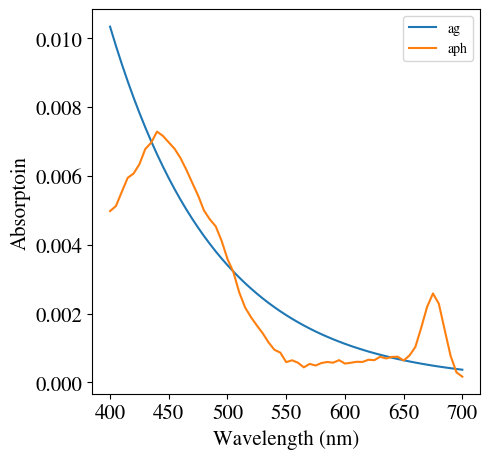

In [19]:
fig = plt.figure(figsize=(5,5)) 
ax = plt.gca()
#
ax.plot(odict['wave'], odict['ag'], label='ag')
ax.plot(odict['wave'], odict['aph'], label='aph')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorptoin')
#
ax.legend()
#
oc_plotting.set_fontsize(ax, 15)
plt.show()

# Standard fit

In [24]:
# Do it
chains, models, prep_dict, idx, extras = l23.fit_one(p, idx)

idx=170
Running burn-in


100%|██████████████████████████████████████████████| 1000/1000 [00:01<00:00, 898.33it/s]


Running full model


100%|████████████████████████████████████████████| 40000/40000 [00:46<00:00, 868.05it/s]


In [24]:
models[0].pnames + models[1].pnames

['Adg', 'Sdg', 'Aph', 'Bnw', 'beta']

## Examine output

In [17]:
def calc_coeff(chains, burn = 7000,  thin = 1):
    coeff = chains[burn::thin, :, :].reshape(-1, chains.shape[-1])
    return coeff

In [26]:
def plot_2d(coeff, xlim=None, ylim=None):
    fig = plt.figure(figsize=(5,5))
    ax = plt.gca()
    #
    plotting.hist2d(coeff[:,0], coeff[:,2])
    # Label
    ax.set_xlabel('a_dg')
    ax.set_ylabel('a_ph')
    # 
    ax.plot(np.log10(true_dg), np.log10(true_ph), 'or')
    #
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    #
    oc_plotting.set_fontsize(ax,15)
    plt.show()

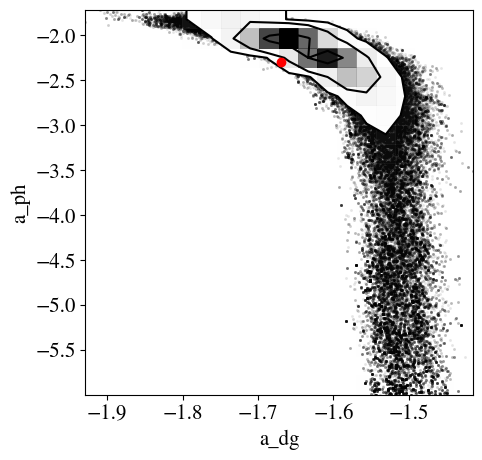

In [25]:
coeff = calc_coeff(chains)
plot_2d(coeff)

# Fit with the additional prior

In [14]:
p2 = standard.expb_pow(scl_noise='PACE', nsteps=40000, add_noise=True,
                       othera_priors=[dict(flavor='ratio', ratio=2.0, sigma=0.3,
                                          i0=0, i1=2)])

In [35]:
chains2, models2, prep_dict2, idx, extras2 = l23.fit_one(p2, idx)

idx=170
Running burn-in


100%|█████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1274.36it/s]


Running full model


100%|███████████████████████████████████████████| 40000/40000 [00:30<00:00, 1290.44it/s]


In [18]:
coeff2 = calc_coeff(chains2)

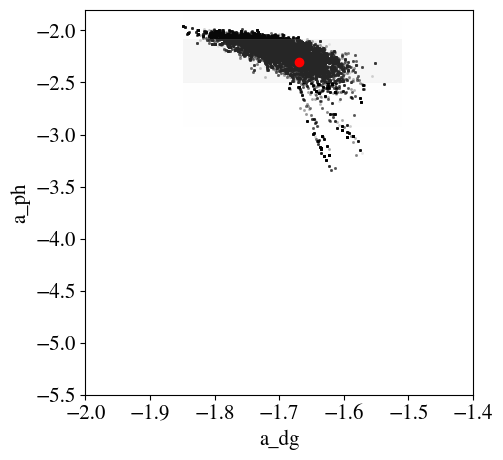

In [33]:
plot_2d(coeff2, xlim=(-2., -1.4), ylim=(-5.5,-1.8))
#plot_2d(coeff2, xlim=(4., 5), ylim=(4,5))

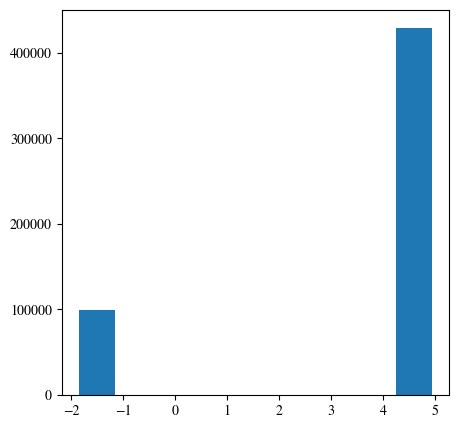

In [32]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()
ax.hist(coeff2[:,0])
#
plt.show()

In [31]:
coeff2.shape

(528000, 5)

## Model

In [34]:
def show(prep_dict, extras, models, chains):
    odict = prep_dict['odict']
    pdict = prep_dict['pdict']
    plotting.show_fits(
        models, chains, 
        extras['Chl'], extras['Y'],
        Rrs_true=dict(wave=models[0].wave, spec=prep_dict['model_Rrs']),
        anw_true=dict(wave=odict['true_wave'], spec=odict['anw']),
        bbnw_true=dict(wave=odict['true_wave'], spec=odict['bbnw']),
        perc=(16, 84),
        )
    plt.show()

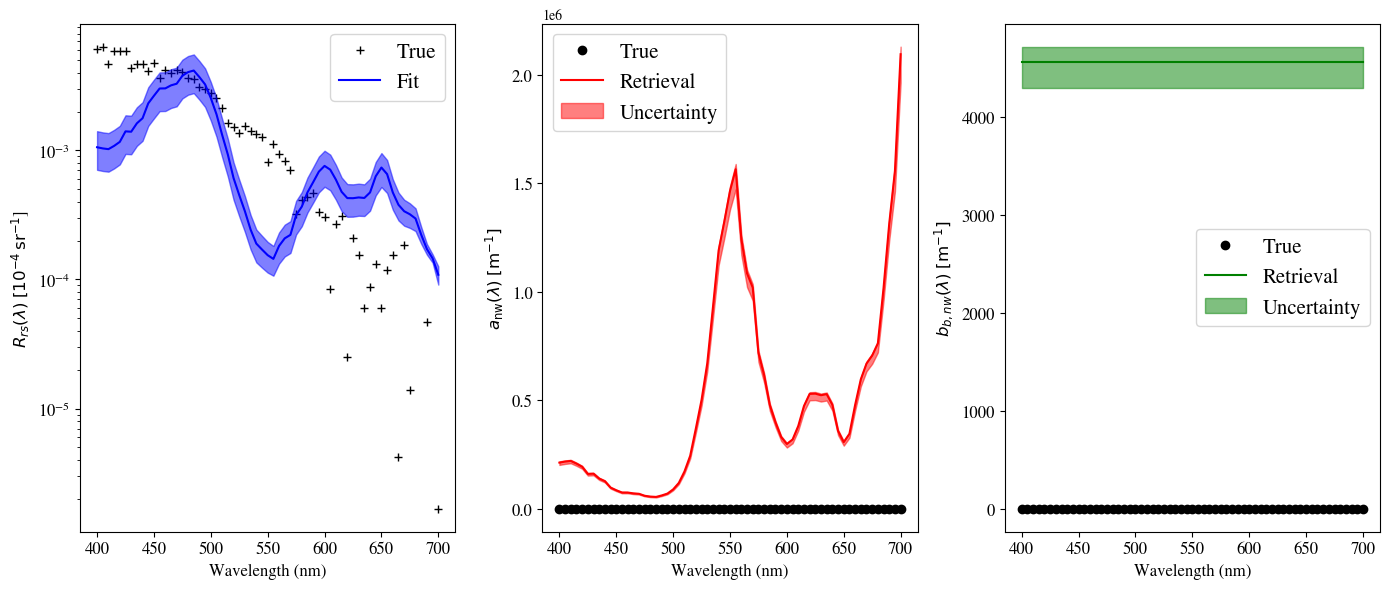

In [36]:
show(prep_dict2, extras2, models2, chains2)

----

# Testing

In [8]:
reload(l23)
pdict = l23.prep_one_l23(p2, idx)

In [9]:
pdict['models'][0].priors

<Priors: 
  <Prior: log_uniform, pmin=-6.000, pmax=5.000 >
  <Prior: uniform, pmin=0.010, pmax=0.020 >
  <Prior: log_uniform, pmin=-6.000, pmax=5.000 >
  <Prior: ratio, mean=2.000, sigma=0.300 >
>

In [10]:
10**pdict['p0']

array([0.0131865 , 1.03992017, 0.0131865 , 1.00074095, 1.        ])

In [11]:
pdict['models'][0].priors.calc(pdict['p0'][:pdict['models'][0].nparam])

np.float64(-5.555555555555556)

In [12]:
pdict['p0']

array([-1.87987045e+00,  1.70000000e-02, -1.87987045e+00,  3.21669999e-04,
        0.00000000e+00])

In [13]:
-0.5 * ( (0.01319 - 2*0.01319)/(0.3*0.01319))**2

-5.555555555555557